# OcuScan AI — EDA Notebook
**Phase 1, Day 5 Deliverable**  
6-class anterior segment dataset: Normal · OCP · OCP Chronic · Post-Viral DED · SJS · Symblepharon

Sections:
1. Setup & imports
2. Dataset inventory
3. Class distribution bar chart
4. 5 sample images per class grid
5. Resolution scatter plot
6. Pixel histograms per class
7. Mean image per class (OCP vs OCP Chronic focus)
8. Train/Val/Test split verification
9. Flagged (ambiguous) image summary

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm

from dataset import (
    CLASS_NAMES, CLASS_TO_IDX,
    DATASET_DIR, LABELS_CSV, PROJECT_ROOT,
    build_labels_csv, apply_stratified_split,
    verify_no_leakage, verify_split_counts
)

# Plotting style
sns.set_theme(style='whitegrid', palette='muted')
FIGURES_DIR = PROJECT_ROOT / 'results'
FIGURES_DIR.mkdir(exist_ok=True)

CLASS_COLOURS = {
    'normal':         '#2E7D32',
    'ocp':            '#F57C00',
    'ocp_chronic':    '#C62828',
    'post_viral_ded': '#1565C0',
    'sjs':            '#FF6F00',
    'symblepharon':   '#B71C1C',
}

print('Setup complete. PROJECT_ROOT:', PROJECT_ROOT)

Setup complete. PROJECT_ROOT: C:\Users\gkv47\Downloads\projectai\notebooks\..


## 1. Dataset Inventory

In [2]:
# Build or load labels.csv
if not LABELS_CSV.exists():
    print('Building labels.csv...')
    df = build_labels_csv()
    df = apply_stratified_split(df)
    df.to_csv(LABELS_CSV, index=False)
    print('labels.csv created.')
else:
    df = pd.read_csv(LABELS_CSV)
    if 'split' not in df.columns or df['split'].eq('').all():
        df = apply_stratified_split(df)
        df.to_csv(LABELS_CSV, index=False)
    print(f'Loaded labels.csv: {len(df)} images')

print(df.head())
print('\nColumns:', df.columns.tolist())

Loaded labels.csv: 60 images
                      filepath class_key  class_idx  split  ambiguous_flag  \
0  dataset/normal/test_000.jpg    normal          0  train               0   
1  dataset/normal/test_001.jpg    normal          0  train               0   
2  dataset/normal/test_002.jpg    normal          0  train               0   
3  dataset/normal/test_003.jpg    normal          0   test               0   
4  dataset/normal/test_004.jpg    normal          0    val               0   

   ambiguous_note  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  

Columns: ['filepath', 'class_key', 'class_idx', 'split', 'ambiguous_flag', 'ambiguous_note']


In [3]:
# Summary table
summary = df.groupby(['class_key', 'split']).size().unstack(fill_value=0)
summary['total'] = summary.sum(axis=1)
summary = summary.reindex(CLASS_NAMES)
print('Per-class split summary:')
print(summary.to_string())
print(f'\nTotal images: {len(df)}')

Per-class split summary:
split           test  train  val  total
class_key                              
normal             1      7    2     10
ocp                1      7    2     10
ocp_chronic        2      7    1     10
post_viral_ded     2      7    1     10
sjs                2      7    1     10
symblepharon       1      7    2     10

Total images: 60


## 2. Class Distribution Bar Chart

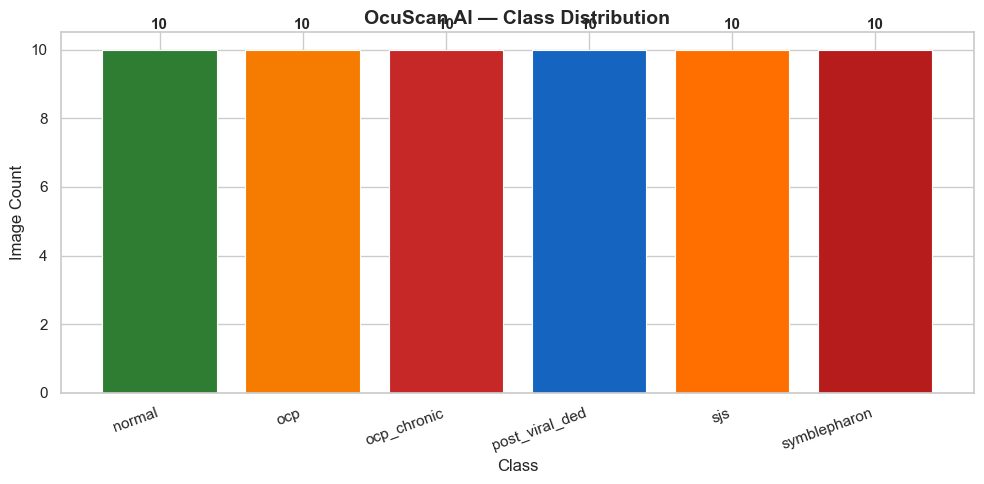

Saved → C:\Users\gkv47\Downloads\projectai\notebooks\..\results\eda_class_distribution.png


In [4]:
class_counts = df.groupby('class_key').size().reindex(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    CLASS_NAMES,
    class_counts.values,
    color=[CLASS_COLOURS[c] for c in CLASS_NAMES],
    edgecolor='white', linewidth=0.8
)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('OcuScan AI — Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Image Count', fontsize=12)
ax.set_xticks(range(len(CLASS_NAMES)))
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')

plt.tight_layout()
save_path = FIGURES_DIR / 'eda_class_distribution.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

## 3. Sample Images Grid (5 per class)

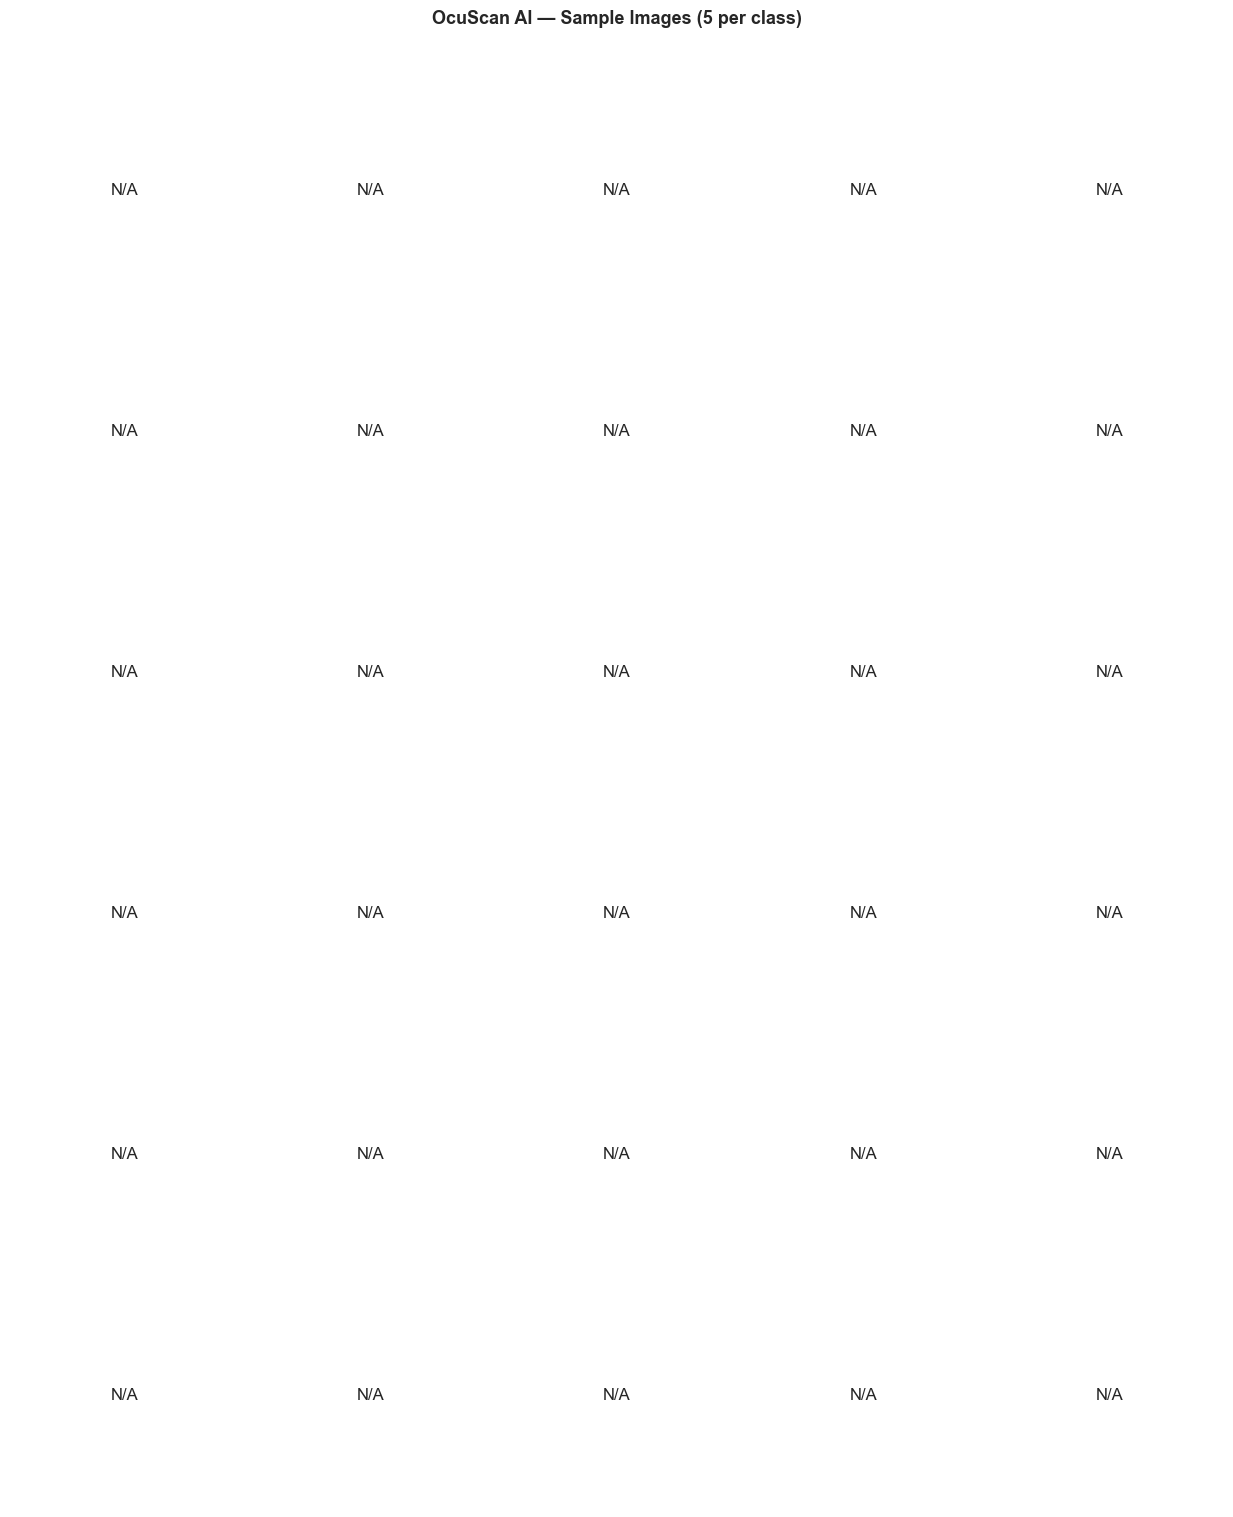

Saved → C:\Users\gkv47\Downloads\projectai\notebooks\..\results\eda_sample_grid.png


In [5]:
N_SAMPLES = 5
fig, axes = plt.subplots(len(CLASS_NAMES), N_SAMPLES, figsize=(N_SAMPLES * 2.5, len(CLASS_NAMES) * 2.5))

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_rows = df[df['class_key'] == cls].sample(min(N_SAMPLES, len(df[df['class_key'] == cls])),
                                                   random_state=42)
    for col_idx in range(N_SAMPLES):
        ax = axes[row_idx][col_idx]
        if col_idx < len(cls_rows):
            fp = PROJECT_ROOT / cls_rows.iloc[col_idx]['filepath']
            try:
                img = Image.open(fp).convert('RGB')
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9, rotation=0, labelpad=60, va='center',
                          color=CLASS_COLOURS[cls], fontweight='bold')

plt.suptitle('OcuScan AI — Sample Images (5 per class)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
save_path = FIGURES_DIR / 'eda_sample_grid.png'
plt.savefig(save_path, dpi=120, bbox_inches='tight')
plt.show()
print(f'Saved → {save_path}')

## 4. Resolution Scatter Plot

In [6]:
widths, heights, cls_list = [], [], []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Reading resolutions'):
    try:
        fp = PROJECT_ROOT / row['filepath']
        with Image.open(fp) as img:
            widths.append(img.width)
            heights.append(img.height)
            cls_list.append(row['class_key'])
    except Exception:
        widths.append(0); heights.append(0); cls_list.append(row['class_key'])

res_df = pd.DataFrame({'width': widths, 'height': heights, 'class_key': cls_list})

fig, ax = plt.subplots(figsize=(9, 6))
for cls in CLASS_NAMES:
    sub = res_df[res_df['class_key'] == cls]
    ax.scatter(sub['width'], sub['height'], label=cls, alpha=0.6,
               color=CLASS_COLOURS[cls], edgecolors='white', linewidths=0.4, s=40)

ax.axvline(224, color='gray', linestyle='--', linewidth=1, label='224px (model input)')
ax.axhline(224, color='gray', linestyle='--', linewidth=1)
ax.set_title('Image Resolution Distribution by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Width (px)'); ax.set_ylabel('Height (px)')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
save_path = FIGURES_DIR / 'eda_resolution_scatter.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

## 5. Pixel Histograms per Class

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, cls in enumerate(CLASS_NAMES):
    ax = axes[idx]
    cls_rows = df[df['class_key'] == cls].head(20)  # sample 20 for speed
    all_pixels = []

    for _, row in cls_rows.iterrows():
        try:
            fp = PROJECT_ROOT / row['filepath']
            img_np = np.array(Image.open(fp).convert('L').resize((224, 224)))
            all_pixels.extend(img_np.flatten().tolist())
        except Exception:
            pass

    if all_pixels:
        ax.hist(all_pixels, bins=64, color=CLASS_COLOURS[cls], alpha=0.8, edgecolor='none')
    else:
        ax.text(0.5, 0.5, 'No images', ha='center', va='center', transform=ax.transAxes)

    ax.set_title(cls, fontsize=11, fontweight='bold', color=CLASS_COLOURS[cls])
    ax.set_xlabel('Pixel intensity (grayscale)')
    ax.set_ylabel('Frequency')
    ax.set_xlim(0, 255)

plt.suptitle('Pixel Intensity Histograms per Class (grayscale)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_path = FIGURES_DIR / 'eda_pixel_histograms.png'
plt.savefig(save_path, dpi=120)
plt.show()
print(f'Saved → {save_path}')

## 6. Mean Image per Class (OCP vs OCP Chronic focus)

In [ ]:
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(len(CLASS_NAMES) * 3, 3.5))
TARGET_SIZE = (224, 224)

for idx, cls in enumerate(CLASS_NAMES):
    cls_rows = df[df['class_key'] == cls]
    stacked = []
    for _, row in cls_rows.iterrows():
        try:
            fp = PROJECT_ROOT / row['filepath']
            img_np = np.array(Image.open(fp).convert('RGB').resize(TARGET_SIZE), dtype=np.float32)
            stacked.append(img_np)
        except Exception:
            pass

    ax = axes[idx]
    if stacked:
        mean_img = np.mean(stacked, axis=0).astype(np.uint8)
        ax.imshow(mean_img)
        ax.set_title(f'{cls}\n(n={len(stacked)})', fontsize=9, fontweight='bold',
                     color=CLASS_COLOURS[cls])
    else:
        ax.text(0.5, 0.5, 'No images', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(cls, fontsize=9)
    ax.axis('off')

plt.suptitle('Mean Image per Class — OCP vs OCP Chronic comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout()
save_path = FIGURES_DIR / 'eda_mean_images.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

## 7. Train/Val/Test Split Verification

In [ ]:
print('=== Split Verification ===')
verify_no_leakage(df)
split_summary = verify_split_counts(df)

# Stacked bar chart
split_df = pd.DataFrame(split_summary).T.reindex(CLASS_NAMES)
fig, ax = plt.subplots(figsize=(10, 5))
split_df[['train', 'val', 'test']].plot(
    kind='bar', ax=ax, color=['#1976D2', '#FF8F00', '#388E3C'],
    edgecolor='white', linewidth=0.5
)
ax.set_title('Train / Val / Test Split per Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Image Count')
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha='right')
ax.legend(['Train (70%)', 'Val (15%)', 'Test (15%)'])
plt.tight_layout()
save_path = FIGURES_DIR / 'eda_split_distribution.png'
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Saved → {save_path}')

## 8. Flagged (Ambiguous) Image Summary

In [ ]:
if 'ambiguous_flag' in df.columns:
    flagged = df[df['ambiguous_flag'] == 1]
    print(f'Flagged images: {len(flagged)} / {len(df)} ({100*len(flagged)/max(len(df),1):.1f}%)')
    if len(flagged) > 0:
        print(flagged[['filepath', 'class_key', 'ambiguous_note']].to_string())
    else:
        print('No ambiguous images flagged.')
else:
    print('ambiguous_flag column not present in labels.csv')

print('\n=== EDA Complete ===')
print(f'All figures saved to: {FIGURES_DIR}')